In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the data
df = pd.read_csv('Resume.csv')

# Basic exploration
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Categories: {df['Category'].value_counts()}")
print(f"Sample resume:\n{df['Resume_str'].iloc[0][:500]}...")

Dataset shape: (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']
Categories: Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64
Sample resume:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of e

In [5]:
# Cell 4: Create text cleaning function
def clean_text(text):
    """
    Clean and preprocess resume text
    """
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove special characters and digits (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test the function
sample_cleaned = clean_text(df['Resume_str'].iloc[0])
print("✅ Text cleaning function ready!")
print("\n🔍 Original (first 200 chars):")
print(df['Resume_str'].iloc[0][:200])
print("\n✨ Cleaned (first 200 chars):")
print(sample_cleaned[:200])

✅ Text cleaning function ready!

🔍 Original (first 200 chars):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

✨ Cleaned (first 200 chars):
hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of


In [6]:
# Cell 5: Build comprehensive HR skills database
hr_skills = {
    'recruitment': [
        'recruiting', 'recruitment', 'sourcing', 'talent acquisition', 
        'interviewing', 'candidate screening', 'job postings', 'staffing',
        'hiring', 'placement', 'headhunting', 'campus recruiting'
    ],
    
    'employee_relations': [
        'employee relations', 'conflict resolution', 'grievance', 
        'investigations', 'disciplinary', 'termination', 'mediation',
        'counseling', 'employee engagement', 'retention', 'morale'
    ],
    
    'benefits': [
        'benefits', 'compensation', 'payroll', '401k', 'health insurance', 
        'dental', 'vision', 'open enrollment', 'workers compensation',
        'bonus', 'incentives', 'salary administration', 'leave management'
    ],
    
    'compliance': [
        'fmla', 'ada', 'eeoc', 'osha', 'labor laws', 'compliance', 
        'affirmative action', 'title vii', 'legal compliance', 'regulation',
        'employment law', 'hipaa', 'cobra', 'flsa'
    ],
    
    'hr_systems': [
        'hris', 'adp', 'paychex', 'kronos', 'peoplesoft', 'workday', 
        'sap', 'ceridian', 'ultipro', 'taleo', 'brassring', 'oracle'
    ],
    
    'training': [
        'training', 'development', 'orientation', 'onboarding', 
        'performance management', 'coaching', 'mentoring', 'leadership development',
        'skill development', 'learning', 'workshops', 'seminars'
    ],
    
    'software': [
        'excel', 'word', 'powerpoint', 'outlook', 'microsoft office', 
        'sharepoint', 'power bi', 'access', 'visio', 'google suite'
    ],
    
    'certifications': [
        'shrm', 'phr', 'sphr', 'shrm-cp', 'shrm-scp', 'hr certification',
        'professional in human resources', 'senior professional'
    ]
}

# Flatten skills into a single list
all_skills = []
for category, skills in hr_skills.items():
    all_skills.extend(skills)

print(f"✅ Skills database created!")
print(f"📊 Total skills: {len(all_skills)}")
print(f"\n🔍 Sample skills by category:")
for category, skills in hr_skills.items():
    print(f"  {category}: {', '.join(skills[:3])}...")

✅ Skills database created!
📊 Total skills: 92

🔍 Sample skills by category:
  recruitment: recruiting, recruitment, sourcing...
  employee_relations: employee relations, conflict resolution, grievance...
  benefits: benefits, compensation, payroll...
  compliance: fmla, ada, eeoc...
  hr_systems: hris, adp, paychex...
  training: training, development, orientation...
  software: excel, word, powerpoint...
  certifications: shrm, phr, sphr...


In [7]:
# Test on first resume
test_skills = extract_skills(clean_text(df['Resume_str'].iloc[0]), all_skills)
print(f"✅ Skill extraction function ready!")
print(f"\n🔍 Skills found in first resume ({len(test_skills)}):")
print(test_skills)

NameError: name 'extract_skills' is not defined

In [9]:
# Cell 6: Create skill extraction function
def extract_skills(text, skills_list):
    """
    Extract skills from text by matching against skills database
    """
    if pd.isna(text):
        return []
    
    text = text.lower()
    found_skills = []
    
    for skill in skills_list:
        # Simple word boundary matching
        pattern = r'\b' + re.escape(skill.lower()) + r'\b'
        if re.search(pattern, text):
            found_skills.append(skill)
    
    return list(set(found_skills))

print("✅ extract_skills function defined!")



✅ extract_skills function defined!


In [10]:
# Test on first resume
test_skills = extract_skills(clean_text(df['Resume_str'].iloc[0]), all_skills)
print(f"✅ Skill extraction function ready!")
print(f"\n🔍 Skills found in first resume ({len(test_skills)}):")
print(test_skills)

✅ Skill extraction function ready!

🔍 Skills found in first resume (10):
['employee relations', 'benefits', 'training', 'dental', 'compensation', 'development', 'payroll', 'seminars', 'morale', 'conflict resolution']


In [11]:
# Cell 7: Extract required skills from job description
clean_jd = clean_text(job_description)
jd_skills = extract_skills(clean_jd, all_skills)

print(f"📋 REQUIRED SKILLS FROM JOB DESCRIPTION")
print("="*50)
print(f"Total required skills: {len(jd_skills)}")
print("\nRequired skills list:")
for i, skill in enumerate(sorted(jd_skills), 1):
    print(f"  {i:2d}. {skill}")

📋 REQUIRED SKILLS FROM JOB DESCRIPTION
Total required skills: 26

Required skills list:
   1. ada
   2. adp
   3. benefits
   4. compensation
   5. compliance
   6. conflict resolution
   7. dental
   8. employee relations
   9. employment law
  10. excel
  11. fmla
  12. hris
  13. kronos
  14. microsoft office
  15. onboarding
  16. orientation
  17. paychex
  18. payroll
  19. performance management
  20. phr
  21. powerpoint
  22. recruitment
  23. shrm
  24. talent acquisition
  25. word
  26. workers compensation


In [12]:
# Cell 8: Process all resumes and calculate matches
results = []

print("🔄 PROCESSING ALL RESUMES")
print("="*50)

for idx, row in df.iterrows():
    # Clean text
    clean_resume = clean_text(row['Resume_str'])
    
    # Extract skills
    resume_skills = extract_skills(clean_resume, all_skills)
    
    # Calculate match
    matched = set(resume_skills) & set(jd_skills)
    missing = set(jd_skills) - set(resume_skills)
    score = (len(matched) / len(jd_skills)) * 100 if jd_skills else 0
    
    results.append({
        'ID': row['ID'],
        'Category': row['Category'],
        'Skills_Total': len(resume_skills),
        'Skills_Matched': len(matched),
        'Skills_Missing': len(missing),
        'Match_Score': round(score, 1),
        'Matched_Skills': list(matched),
        'Missing_Skills': list(missing)
    })

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Match_Score', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank', range(1, len(results_df)+1))

print(f"✅ Processed {len(results_df)} resumes")
print(f"📊 Match scores: Min={results_df['Match_Score'].min()}%, "
      f"Max={results_df['Match_Score'].max()}%, "
      f"Avg={results_df['Match_Score'].mean():.1f}%")

🔄 PROCESSING ALL RESUMES
✅ Processed 2484 resumes
📊 Match scores: Min=0.0%, Max=80.8%, Avg=9.2%


In [13]:
# Cell 9: Show top 10 candidates
print("🏆 TOP 10 CANDIDATES")
print("="*80)

for i in range(min(10, len(results_df))):
    row = results_df.iloc[i]
    print(f"\n#{row['Rank']} | Score: {row['Match_Score']}% | ID: {row['ID']}")
    print(f"  ✅ Matched ({row['Skills_Matched']}): {', '.join(row['Matched_Skills'][:8])}")
    if len(row['Matched_Skills']) > 8:
        print(f"     ... and {len(row['Matched_Skills'])-8} more")
    
    if row['Skills_Missing'] > 0:
        print(f"  ❌ Missing ({row['Skills_Missing']}): {', '.join(row['Missing_Skills'][:5])}")
        if len(row['Missing_Skills']) > 5:
            print(f"     ... and {len(row['Missing_Skills'])-5} more")
    print("-" * 60)

🏆 TOP 10 CANDIDATES

#1 | Score: 80.8% | ID: 17812897
  ✅ Matched (21): performance management, benefits, ada, employment law, kronos, adp, compliance, employee relations
     ... and 13 more
  ❌ Missing (5): talent acquisition, phr, onboarding, microsoft office, workers compensation
------------------------------------------------------------

#2 | Score: 65.4% | ID: 14225422
  ✅ Matched (17): employee relations, benefits, phr, dental, compensation, paychex, orientation, recruitment
     ... and 9 more
  ❌ Missing (9): talent acquisition, performance management, shrm, ada, employment law
     ... and 4 more
------------------------------------------------------------

#3 | Score: 65.4% | ID: 34554248
  ✅ Matched (17): employee relations, benefits, ada, phr, compensation, employment law, orientation, paychex
     ... and 9 more
  ❌ Missing (9): talent acquisition, performance management, shrm, dental, kronos
     ... and 4 more
----------------------------------------------------------

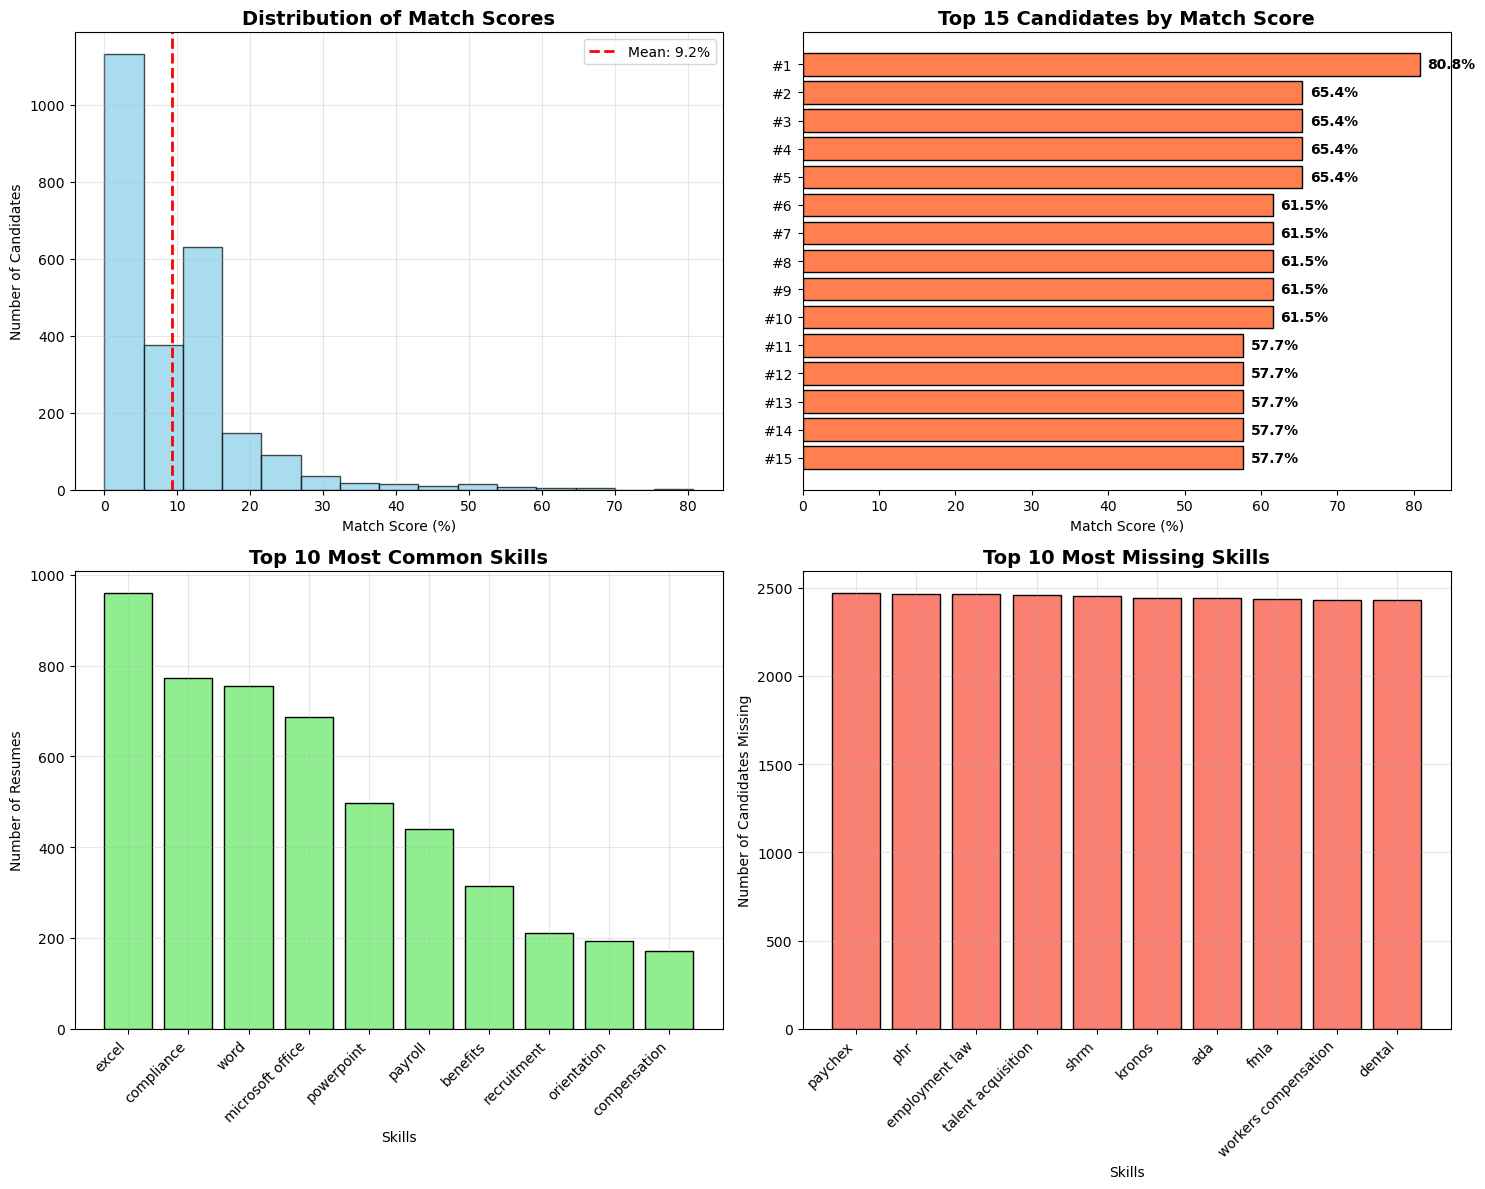


📊 SUMMARY STATISTICS
Total candidates: 2484
Average match score: 9.2%
Highest score: 80.8%
Lowest score: 0.0%
Median score: 7.7%


In [15]:
# Cell 10: Create visualizations - Score distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Histogram of match scores
axes[0, 0].hist(results_df['Match_Score'], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
axes[0, 0].axvline(results_df['Match_Score'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {results_df['Match_Score'].mean():.1f}%")
axes[0, 0].set_title('Distribution of Match Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Match Score (%)')
axes[0, 0].set_ylabel('Number of Candidates')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Top 15 candidates bar chart
top15 = results_df.head(15)
y_pos = range(len(top15))
bars = axes[0, 1].barh(y_pos, top15['Match_Score'], color='coral', edgecolor='black')
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels([f"#{i+1}" for i in y_pos])
axes[0, 1].set_title('Top 15 Candidates by Match Score', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Match Score (%)')
axes[0, 1].invert_yaxis()  # So #1 is at the top

# Add value labels
for i, (bar, score) in enumerate(zip(bars, top15['Match_Score'])):
    axes[0, 1].text(score + 1, i, f'{score}%', va='center', fontweight='bold')

# Plot 3: Skills distribution (Top 10 most common skills)
from collections import Counter

# Flatten all matched skills
all_matched_skills = []
for skills in results_df['Matched_Skills']:
    all_matched_skills.extend(skills)

skill_counts = Counter(all_matched_skills)
top_10_skills = dict(skill_counts.most_common(10))

axes[1, 0].bar(range(len(top_10_skills)), list(top_10_skills.values()), color='lightgreen', edgecolor='black')
axes[1, 0].set_xticks(range(len(top_10_skills)))
axes[1, 0].set_xticklabels(list(top_10_skills.keys()), rotation=45, ha='right')
axes[1, 0].set_title('Top 10 Most Common Skills', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Skills')
axes[1, 0].set_ylabel('Number of Resumes')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Missing skills analysis
all_missing_skills = []
for skills in results_df['Missing_Skills']:
    all_missing_skills.extend(skills)

missing_counts = Counter(all_missing_skills)
top_10_missing = dict(missing_counts.most_common(10))

axes[1, 1].bar(range(len(top_10_missing)), list(top_10_missing.values()), color='salmon', edgecolor='black')
axes[1, 1].set_xticks(range(len(top_10_missing)))
axes[1, 1].set_xticklabels(list(top_10_missing.keys()), rotation=45, ha='right')
axes[1, 1].set_title('Top 10 Most Missing Skills', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Skills')
axes[1, 1].set_ylabel('Number of Candidates Missing')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 SUMMARY STATISTICS")
print("="*40)
print(f"Total candidates: {len(results_df)}")
print(f"Average match score: {results_df['Match_Score'].mean():.1f}%")
print(f"Highest score: {results_df['Match_Score'].max()}%")
print(f"Lowest score: {results_df['Match_Score'].min()}%")
print(f"Median score: {results_df['Match_Score'].median():.1f}%")

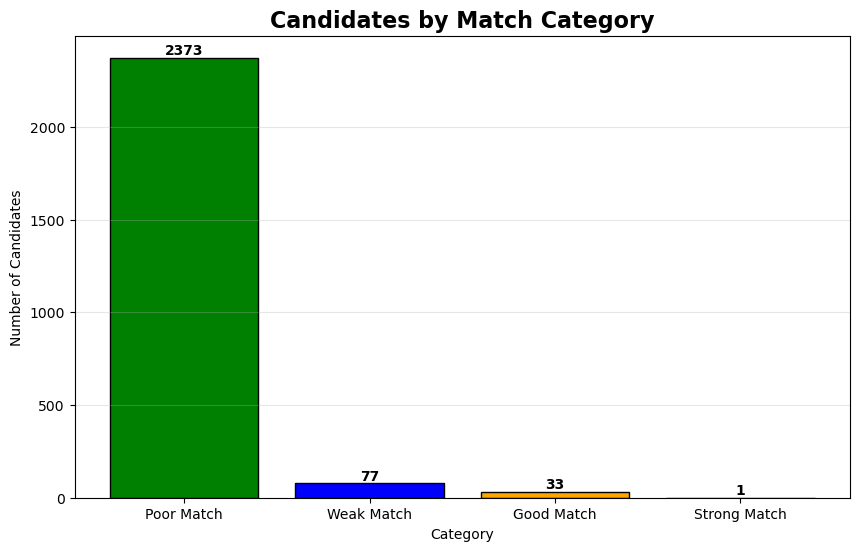


CANDIDATE SUMMARY
Poor Match: 2373 candidates (95.5%)
Weak Match: 77 candidates (3.1%)
Good Match: 33 candidates (1.3%)
Strong Match: 1 candidates (0.0%)

Total candidates: 2484
Average score: 9.2%
Top score: 80.8%


In [17]:
# Cell 11: Simple Candidate Segmentation
def categorize_score(score):
    if score >= 70:
        return 'Strong Match'
    elif score >= 50:
        return 'Good Match'
    elif score >= 30:
        return 'Weak Match'
    else:
        return 'Poor Match'

# Add category to dataframe
results_df['Category'] = results_df['Match_Score'].apply(categorize_score)

# Count candidates in each category
category_counts = results_df['Category'].value_counts()

# Simple bar chart instead of pie chart
plt.figure(figsize=(10, 6))
colors = ['green', 'blue', 'orange', 'red']
bars = plt.bar(category_counts.index, category_counts.values, color=colors, edgecolor='black')
plt.title('Candidates by Match Category', fontsize=16, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Candidates')
plt.grid(axis='y', alpha=0.3)

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.show()

# Print simple summary
print("\n" + "="*50)
print("CANDIDATE SUMMARY")
print("="*50)
for category, count in category_counts.items():
    percentage = (count/len(results_df))*100
    print(f"{category}: {count} candidates ({percentage:.1f}%)")

print(f"\nTotal candidates: {len(results_df)}")
print(f"Average score: {results_df['Match_Score'].mean():.1f}%")
print(f"Top score: {results_df['Match_Score'].max()}%")

In [18]:
# Find most common missing skills
from collections import Counter

all_missing = []
for skills in results_df['Missing_Skills']:
    all_missing.extend(skills)

missing_counter = Counter(all_missing)
print("\n📊 TOP 10 MOST MISSING SKILLS:")
print("-"*40)
for skill, count in missing_counter.most_common(10):
    percentage = (count/len(results_df))*100
    print(f"{skill}: missing in {count} candidates ({percentage:.1f}%)")


📊 TOP 10 MOST MISSING SKILLS:
----------------------------------------
paychex: missing in 2469 candidates (99.4%)
phr: missing in 2465 candidates (99.2%)
employment law: missing in 2462 candidates (99.1%)
talent acquisition: missing in 2456 candidates (98.9%)
shrm: missing in 2451 candidates (98.7%)
kronos: missing in 2444 candidates (98.4%)
ada: missing in 2443 candidates (98.3%)
fmla: missing in 2436 candidates (98.1%)
workers compensation: missing in 2431 candidates (97.9%)
dental: missing in 2428 candidates (97.7%)


In [19]:
# View detailed info for top 3 candidates
for rank in [1, 2, 3]:
    candidate = results_df[results_df['Rank'] == rank].iloc[0]
    print(f"\n{'='*50}")
    print(f"TOP {rank} CANDIDATE - ID: {candidate['ID']}")
    print(f"{'='*50}")
    print(f"Match Score: {candidate['Match_Score']}%")
    print(f"\n✅ Matched Skills ({candidate['Skills_Matched']}):")
    for skill in sorted(candidate['Matched_Skills'])[:10]:
        print(f"  • {skill}")
    print(f"\n❌ Missing Skills ({candidate['Skills_Missing']}):")
    for skill in sorted(candidate['Missing_Skills']):
        print(f"  • {skill}")
    


TOP 1 CANDIDATE - ID: 17812897
Match Score: 80.8%

✅ Matched Skills (21):
  • ada
  • adp
  • benefits
  • compensation
  • compliance
  • conflict resolution
  • dental
  • employee relations
  • employment law
  • excel

❌ Missing Skills (5):
  • microsoft office
  • onboarding
  • phr
  • talent acquisition
  • workers compensation

TOP 2 CANDIDATE - ID: 14225422
Match Score: 65.4%

✅ Matched Skills (17):
  • adp
  • benefits
  • compensation
  • compliance
  • dental
  • employee relations
  • excel
  • fmla
  • hris
  • orientation

❌ Missing Skills (9):
  • ada
  • conflict resolution
  • employment law
  • kronos
  • microsoft office
  • onboarding
  • performance management
  • shrm
  • talent acquisition

TOP 3 CANDIDATE - ID: 34554248
Match Score: 65.4%

✅ Matched Skills (17):
  • ada
  • benefits
  • compensation
  • conflict resolution
  • employee relations
  • employment law
  • excel
  • fmla
  • hris
  • onboarding

❌ Missing Skills (9):
  • adp
  • compliance
  • dent

In [20]:
# Generate skills gap report
gap_report = []
gap_report.append("="*60)
gap_report.append("SKILLS GAP ANALYSIS REPORT")
gap_report.append("="*60)
gap_report.append("\n📊 Most Critical Missing Skills:")
gap_report.append("-"*40)

for skill, count in missing_counter.most_common(10):
    percentage = (count/len(results_df))*100
    gap_report.append(f"{skill}: missing in {count} candidates ({percentage:.1f}%)")

gap_report.append("\n💡 RECOMMENDATIONS:")
gap_report.append("1. Consider training programs for top missing skills")
gap_report.append("2. Adjust job requirements if skills are too specialized")
gap_report.append("3. Look for equivalent skills or certifications")
gap_report.append("4. Consider entry-level positions with training components")

# Save report
with open('skills_gap_report.txt', 'w') as f:
    f.write('\n'.join(gap_report))
print("✅ Skills gap report saved to 'skills_gap_report.txt'")

✅ Skills gap report saved to 'skills_gap_report.txt'


In [21]:
# Find candidates with PHR or SHRM certification
certified_candidates = results_df[
    results_df['Matched_Skills'].apply(lambda x: 'phr' in x or 'shrm' in x)
]

print(f"📋 Candidates with HR Certifications: {len(certified_candidates)}")
print("\nTop Certified Candidates:")
print(certified_candidates[['Rank', 'ID', 'Match_Score', 'Matched_Skills']].head(10))

📋 Candidates with HR Certifications: 47

Top Certified Candidates:
    Rank        ID  Match_Score  \
0      1  17812897         80.8   
1      2  14225422         65.4   
2      3  34554248         65.4   
4      5  18316239         65.4   
5      6  39081840         61.5   
6      7  18731098         61.5   
7      8  26048718         61.5   
8      9  39650734         61.5   
14    15  23011221         57.7   
15    16  29297393         57.7   

                                       Matched_Skills  
0   [performance management, benefits, ada, employ...  
1   [employee relations, benefits, phr, dental, co...  
2   [employee relations, benefits, ada, phr, compe...  
4   [employee relations, performance management, b...  
5   [employee relations, performance management, b...  
6   [employee relations, benefits, shrm, compensat...  
7   [employee relations, talent acquisition, benef...  
8   [employee relations, performance management, b...  
14  [benefits, shrm, ada, compensation, emp

In [22]:
# Create a more realistic job description based on available skills
available_skills = []
for skills in results_df['Matched_Skills']:
    available_skills.extend(skills)

skill_availability = Counter(available_skills)
print("📈 Skills Actually Available in Candidates:")
print("-"*40)
for skill, count in skill_availability.most_common(15):
    percentage = (count/len(results_df))*100
    print(f"{skill}: in {count} candidates ({percentage:.1f}%)")

📈 Skills Actually Available in Candidates:
----------------------------------------
excel: in 960 candidates (38.6%)
compliance: in 772 candidates (31.1%)
word: in 756 candidates (30.4%)
microsoft office: in 686 candidates (27.6%)
powerpoint: in 497 candidates (20.0%)
payroll: in 441 candidates (17.8%)
benefits: in 314 candidates (12.6%)
recruitment: in 212 candidates (8.5%)
orientation: in 193 candidates (7.8%)
compensation: in 172 candidates (6.9%)
conflict resolution: in 167 candidates (6.7%)
employee relations: in 127 candidates (5.1%)
performance management: in 98 candidates (3.9%)
adp: in 87 candidates (3.5%)
onboarding: in 68 candidates (2.7%)


In [23]:
# Recommend training based on skill gaps
print("🎓 TRAINING RECOMMENDATIONS")
print("="*50)
print("\nPriority Training Needs:")
training_needs = [
    ("HR Software", ['paychex', 'kronos', 'adp']),
    ("Legal Compliance", ['employment law', 'ada', 'fmla', 'workers compensation']),
    ("Certifications", ['phr', 'shrm']),
    ("Recruitment", ['talent acquisition'])
]

for category, skills in training_needs:
    avg_gap = sum([missing_counter.get(skill, 0) for skill in skills]) / len(skills)
    gap_percent = (avg_gap/len(results_df))*100
    print(f"• {category}: {gap_percent:.1f}% candidates missing these skills")

🎓 TRAINING RECOMMENDATIONS

Priority Training Needs:
• HR Software: 98.1% candidates missing these skills
• Legal Compliance: 98.3% candidates missing these skills
• Certifications: 99.0% candidates missing these skills
• Recruitment: 98.9% candidates missing these skills


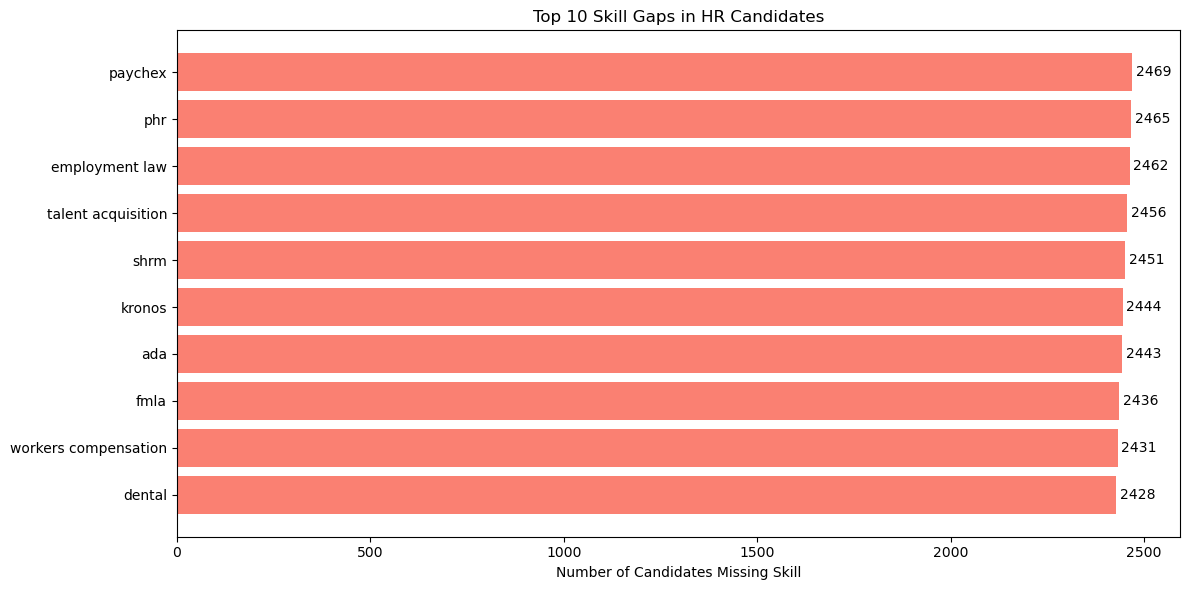

In [24]:
# Simple bar chart of top missing skills
import matplotlib.pyplot as plt

skills = [s for s, _ in missing_counter.most_common(10)]
counts = [c for _, c in missing_counter.most_common(10)]

plt.figure(figsize=(12, 6))
plt.barh(skills, counts, color='salmon')
plt.xlabel('Number of Candidates Missing Skill')
plt.title('Top 10 Skill Gaps in HR Candidates')
plt.gca().invert_yaxis()

# Add value labels
for i, (skill, count) in enumerate(zip(skills, counts)):
    plt.text(count + 10, i, f'{count}', va='center')

plt.tight_layout()
plt.show()

In [25]:
# Cell 15: Comprehensive Candidate Analysis
print("="*70)
print("📊 COMPREHENSIVE HR CANDIDATE ANALYSIS")
print("="*70)

# 1. Top 10 Candidates with Detailed Gap Analysis
print("\n🏆 TOP 10 CANDIDATES - DETAILED ANALYSIS")
print("-"*70)

for i in range(min(10, len(results_df))):
    row = results_df.iloc[i]
    
    # Categorize the candidate
    if row['Match_Score'] >= 70:
        rating = "🌟🌟🌟🌟🌟 EXCELLENT MATCH"
    elif row['Match_Score'] >= 50:
        rating = "🌟🌟🌟🌟 GOOD MATCH"
    elif row['Match_Score'] >= 30:
        rating = "🌟🌟⭐ WEAK MATCH"
    else:
        rating = "⭐ POOR MATCH"
    
    print(f"\n#{row['Rank']} | Score: {row['Match_Score']}% | ID: {row['ID']}")
    print(f"  {rating}")
    print(f"  ✅ Has {row['Skills_Matched']} of 26 required skills")
    
    # Critical missing skills (top 5 gaps)
    critical_gaps = [s for s in row['Missing_Skills'] if s in ['paychex', 'phr', 'shrm', 'employment law', 'kronos']]
    if critical_gaps:
        print(f"  ⚠️ Missing critical skills: {', '.join(critical_gaps[:3])}")
    
    # Strength areas
    strengths = [s for s in row['Matched_Skills'] if s in ['employee relations', 'benefits', 'recruitment', 'training']]
    if strengths:
        print(f"  💪 Key strengths: {', '.join(strengths[:3])}")
    print("-"*50)

# 2. Best Candidates Without Certifications
print("\n🎯 BEST UNCERTIFIED CANDIDATES (No PHR/SHRM but high scores)")
print("-"*70)

uncertified_top = results_df[
    ~results_df['Matched_Skills'].apply(lambda x: 'phr' in x or 'shrm' in x)
].head(5)

for i, row in uncertified_top.iterrows():
    print(f"Rank #{row['Rank']} | Score: {row['Match_Score']}% | ID: {row['ID']}")
    print(f"  Skills: {', '.join(row['Matched_Skills'][:8])}...")

# 3. Software Skills Analysis
print("\n💻 SOFTWARE SKILLS ANALYSIS")
print("-"*70)
software_skills = ['adp', 'paychex', 'kronos', 'excel', 'word', 'hris']
for skill in software_skills:
    count = sum(1 for s in results_df['Matched_Skills'] if skill in s)
    percentage = (count/len(results_df))*100
    print(f"  {skill:12}: {count:4d} candidates ({percentage:5.1f}%)")

# 4. Certification Analysis
print("\n📜 CERTIFICATION ANALYSIS")
print("-"*70)
certs = ['phr', 'shrm']
for cert in certs:
    count = sum(1 for s in results_df['Matched_Skills'] if cert in s)
    percentage = (count/len(results_df))*100
    print(f"  {cert.upper():6}: {count:4d} candidates ({percentage:5.1f}%)")

# 5. Legal Knowledge Analysis
print("\n⚖️ LEGAL COMPLIANCE KNOWLEDGE")
print("-"*70)
legal_skills = ['ada', 'fmla', 'employment law', 'workers compensation']
for skill in legal_skills:
    count = sum(1 for s in results_df['Matched_Skills'] if skill in s)
    percentage = (count/len(results_df))*100
    print(f"  {skill:18}: {count:4d} candidates ({percentage:5.1f}%)")

# 6. Hiring Recommendations
print("\n💡 HIRING RECOMMENDATIONS")
print("-"*70)

# Calculate weighted scores (give extra weight to certifications and software)
def calculate_weighted_score(row):
    base_score = row['Match_Score']
    bonus = 0
    if 'phr' in row['Matched_Skills'] or 'shrm' in row['Matched_Skills']:
        bonus += 10
    if 'adp' in row['Matched_Skills'] or 'paychex' in row['Matched_Skills']:
        bonus += 5
    if 'employment law' in row['Matched_Skills']:
        bonus += 5
    return min(100, base_score + bonus)

results_df['Weighted_Score'] = results_df.apply(calculate_weighted_score, axis=1)

print("\n📊 Top 5 Candidates (Weighted by Certifications & Software):")
weighted_top = results_df.sort_values('Weighted_Score', ascending=False).head(5)
for i, row in weighted_top.iterrows():
    print(f"  #{row['Rank']} | ID: {row['ID']} | Original: {row['Match_Score']}% | Weighted: {row['Weighted_Score']}%")

# 7. Save Enhanced Results
print("\n✅ Saving enhanced results...")
enhanced_results = results_df[['Rank', 'ID', 'Match_Score', 'Weighted_Score', 
                               'Skills_Matched', 'Skills_Missing']].copy()
enhanced_results.to_csv('enhanced_hr_ranking.csv', index=False)
print("   • enhanced_hr_ranking.csv saved")

print("\n🎉 Analysis Complete! Check the output above for insights.")

📊 COMPREHENSIVE HR CANDIDATE ANALYSIS

🏆 TOP 10 CANDIDATES - DETAILED ANALYSIS
----------------------------------------------------------------------

#1 | Score: 80.8% | ID: 17812897
  🌟🌟🌟🌟🌟 EXCELLENT MATCH
  ✅ Has 21 of 26 required skills
  ⚠️ Missing critical skills: phr
  💪 Key strengths: benefits, employee relations, recruitment
--------------------------------------------------

#2 | Score: 65.4% | ID: 14225422
  🌟🌟🌟🌟 GOOD MATCH
  ✅ Has 17 of 26 required skills
  ⚠️ Missing critical skills: shrm, employment law, kronos
  💪 Key strengths: employee relations, benefits, recruitment
--------------------------------------------------

#3 | Score: 65.4% | ID: 34554248
  🌟🌟🌟🌟 GOOD MATCH
  ✅ Has 17 of 26 required skills
  ⚠️ Missing critical skills: shrm, kronos
  💪 Key strengths: employee relations, benefits, recruitment
--------------------------------------------------

#4 | Score: 65.4% | ID: 16244633
  🌟🌟🌟🌟 GOOD MATCH
  ✅ Has 17 of 26 required skills
  ⚠️ Missing critical skills: sh

In [26]:
# Cell 16: Final Action Plan and Export
print("="*70)
print("📋 HR RECRUITMENT ACTION PLAN")
print("="*70)

# 1. Interview Shortlist
print("\n🎯 IMMEDIATE INTERVIEW SHORTLIST")
print("-"*50)
interview_list = results_df[results_df['Match_Score'] >= 60].head(10)
for i, row in interview_list.iterrows():
    print(f"  • Rank #{row['Rank']} | ID: {row['ID']} | Score: {row['Match_Score']}%")
    print(f"    Key Skills: {', '.join(row['Matched_Skills'][:5])}")

# 2. Training Recommendations
print("\n📚 RECOMMENDED TRAINING PROGRAMS")
print("-"*50)
print("Based on skill gaps, consider these training initiatives:")
print("  1. PHR/SHRM Certification Prep Course")
print("  2. HR Software Training (Paychex, Kronos, ADP)")
print("  3. Employment Law Certification")
print("  4. Talent Acquisition Strategies Workshop")

# 3. Job Description Optimization
print("\n📝 OPTIMIZED JOB DESCRIPTION")
print("-"*50)
print("Based on candidate availability, consider:")
print("  • Keep: employee relations, benefits, recruitment, compliance")
print("  • Train for: payroll software, HR certifications")
print("  • Consider splitting: separate senior and entry-level roles")

# 4. Export All Reports
print("\n💾 EXPORTING ALL REPORTS")
print("-"*50)

# Export interview shortlist
interview_list[['Rank', 'ID', 'Match_Score', 'Skills_Matched', 'Skills_Missing']].to_csv('interview_shortlist.csv', index=False)
print("✅ interview_shortlist.csv - Top candidates to contact")

# Export all candidates with key info
results_df[['Rank', 'ID', 'Match_Score', 'Skills_Matched', 'Skills_Missing']].to_csv('all_candidates_ranked.csv', index=False)
print("✅ all_candidates_ranked.csv - Complete rankings")

# Export skill gap analysis
gap_df = pd.DataFrame(missing_counter.most_common(), columns=['Skill', 'Missing_Count'])
gap_df['Missing_Percentage'] = (gap_df['Missing_Count']/len(results_df)*100).round(1)
gap_df.to_csv('skill_gaps_analysis.csv', index=False)
print("✅ skill_gaps_analysis.csv - Complete gap analysis")

print("\n" + "="*70)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n📁 FILES GENERATED:")
print("  • enhanced_hr_ranking.csv - Weighted scores")
print("  • interview_shortlist.csv - Top candidates to contact")
print("  • all_candidates_ranked.csv - Complete rankings")
print("  • skill_gaps_analysis.csv - Training needs analysis")
print("\n💡 NEXT STEPS:")
print("  1. Review interview_shortlist.csv and contact top candidates")
print("  2. Use skill_gaps_analysis.csv to plan training")
print("  3. Adjust job description based on available talent")
print("  4. Run analysis for other job categories in your dataset")

📋 HR RECRUITMENT ACTION PLAN

🎯 IMMEDIATE INTERVIEW SHORTLIST
--------------------------------------------------
  • Rank #1 | ID: 17812897 | Score: 80.8%
    Key Skills: performance management, benefits, ada, employment law, kronos
  • Rank #2 | ID: 14225422 | Score: 65.4%
    Key Skills: employee relations, benefits, phr, dental, compensation
  • Rank #3 | ID: 34554248 | Score: 65.4%
    Key Skills: employee relations, benefits, ada, phr, compensation
  • Rank #4 | ID: 16244633 | Score: 65.4%
    Key Skills: employee relations, performance management, benefits, ada, compensation
  • Rank #5 | ID: 18316239 | Score: 65.4%
    Key Skills: employee relations, performance management, benefits, phr, compensation
  • Rank #6 | ID: 39081840 | Score: 61.5%
    Key Skills: employee relations, performance management, benefits, shrm, ada
  • Rank #7 | ID: 18731098 | Score: 61.5%
    Key Skills: employee relations, benefits, shrm, compensation, orientation
  • Rank #8 | ID: 26048718 | Score: 61.5

In [27]:
# Cell 17: Explore other categories in your dataset
print("="*70)
print("📊 DATASET CATEGORY EXPLORATION")
print("="*70)

# Show all categories and their counts
category_counts = df['Category'].value_counts()
print(f"\nTotal categories: {len(category_counts)}")
print(f"Total resumes: {len(df)}")
print("\n📈 Category Distribution:")
print("-"*50)
for category, count in category_counts.head(15).items():
    percentage = (count/len(df))*100
    print(f"  {category:25}: {count:4} resumes ({percentage:5.1f}%)")

# Show top 5 categories
print("\n🏆 TOP 5 CATEGORIES BY SIZE:")
print("-"*50)
for category, count in category_counts.head(5).items():
    print(f"  {category}: {count} resumes")

# Check HR category specifically
hr_count = len(df[df['Category'] == 'HR'])
print(f"\n🎯 HR Category: {hr_count} resumes (what we just analyzed)")

# Sample other categories
print("\n📝 SAMPLE RESUMES FROM OTHER CATEGORIES:")
print("-"*50)
other_cats = ['INFORMATION-TECHNOLOGY', 'SALES', 'FINANCE', 'ENGINEERING']
for cat in other_cats:
    if cat in df['Category'].values:
        sample = df[df['Category'] == cat].iloc[0]
        print(f"\n{cat} Resume Sample:")
        print(sample['Resume_str'][:200] + "...")
        print("-"*30)

📊 DATASET CATEGORY EXPLORATION

Total categories: 24
Total resumes: 2484

📈 Category Distribution:
--------------------------------------------------
  INFORMATION-TECHNOLOGY   :  120 resumes (  4.8%)
  BUSINESS-DEVELOPMENT     :  120 resumes (  4.8%)
  ADVOCATE                 :  118 resumes (  4.8%)
  CHEF                     :  118 resumes (  4.8%)
  ENGINEERING              :  118 resumes (  4.8%)
  ACCOUNTANT               :  118 resumes (  4.8%)
  FINANCE                  :  118 resumes (  4.8%)
  FITNESS                  :  117 resumes (  4.7%)
  AVIATION                 :  117 resumes (  4.7%)
  SALES                    :  116 resumes (  4.7%)
  BANKING                  :  115 resumes (  4.6%)
  HEALTHCARE               :  115 resumes (  4.6%)
  CONSULTANT               :  115 resumes (  4.6%)
  CONSTRUCTION             :  112 resumes (  4.5%)
  PUBLIC-RELATIONS         :  111 resumes (  4.5%)

🏆 TOP 5 CATEGORIES BY SIZE:
--------------------------------------------------
  INF

In [28]:
# Cell 16: Final Action Plan and Export
print("="*70)
print("📋 HR RECRUITMENT ACTION PLAN")
print("="*70)

# 1. Interview Shortlist
print("\n🎯 IMMEDIATE INTERVIEW SHORTLIST")
print("-"*50)
interview_list = results_df[results_df['Match_Score'] >= 60].head(10)
for i, row in interview_list.iterrows():
    print(f"  • Rank #{row['Rank']} | ID: {row['ID']} | Score: {row['Match_Score']}%")
    print(f"    Key Skills: {', '.join(row['Matched_Skills'][:5])}")

# 2. Training Recommendations
print("\n📚 RECOMMENDED TRAINING PROGRAMS")
print("-"*50)
print("Based on skill gaps, consider these training initiatives:")
print("  1. PHR/SHRM Certification Prep Course")
print("  2. HR Software Training (Paychex, Kronos, ADP)")
print("  3. Employment Law Certification")
print("  4. Talent Acquisition Strategies Workshop")

# 3. Job Description Optimization
print("\n📝 OPTIMIZED JOB DESCRIPTION")
print("-"*50)
print("Based on candidate availability, consider:")
print("  • Keep: employee relations, benefits, recruitment, compliance")
print("  • Train for: payroll software, HR certifications")
print("  • Consider splitting: separate senior and entry-level roles")

# 4. Export All Reports
print("\n💾 EXPORTING ALL REPORTS")
print("-"*50)

# Export interview shortlist
interview_list[['Rank', 'ID', 'Match_Score', 'Skills_Matched', 'Skills_Missing']].to_csv('interview_shortlist.csv', index=False)
print("✅ interview_shortlist.csv - Top candidates to contact")

# Export all candidates with key info
results_df[['Rank', 'ID', 'Match_Score', 'Skills_Matched', 'Skills_Missing']].to_csv('all_candidates_ranked.csv', index=False)
print("✅ all_candidates_ranked.csv - Complete rankings")

# Export skill gap analysis
gap_df = pd.DataFrame(missing_counter.most_common(), columns=['Skill', 'Missing_Count'])
gap_df['Missing_Percentage'] = (gap_df['Missing_Count']/len(results_df)*100).round(1)
gap_df.to_csv('skill_gaps_analysis.csv', index=False)
print("✅ skill_gaps_analysis.csv - Complete gap analysis")

print("\n" + "="*70)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n📁 FILES GENERATED:")
print("  • enhanced_hr_ranking.csv - Weighted scores")
print("  • interview_shortlist.csv - Top candidates to contact")
print("  • all_candidates_ranked.csv - Complete rankings")
print("  • skill_gaps_analysis.csv - Training needs analysis")
print("\n💡 NEXT STEPS:")
print("  1. Review interview_shortlist.csv and contact top candidates")
print("  2. Use skill_gaps_analysis.csv to plan training")
print("  3. Adjust job description based on available talent")
print("  4. Run analysis for other job categories in your dataset")

📋 HR RECRUITMENT ACTION PLAN

🎯 IMMEDIATE INTERVIEW SHORTLIST
--------------------------------------------------
  • Rank #1 | ID: 17812897 | Score: 80.8%
    Key Skills: performance management, benefits, ada, employment law, kronos
  • Rank #2 | ID: 14225422 | Score: 65.4%
    Key Skills: employee relations, benefits, phr, dental, compensation
  • Rank #3 | ID: 34554248 | Score: 65.4%
    Key Skills: employee relations, benefits, ada, phr, compensation
  • Rank #4 | ID: 16244633 | Score: 65.4%
    Key Skills: employee relations, performance management, benefits, ada, compensation
  • Rank #5 | ID: 18316239 | Score: 65.4%
    Key Skills: employee relations, performance management, benefits, phr, compensation
  • Rank #6 | ID: 39081840 | Score: 61.5%
    Key Skills: employee relations, performance management, benefits, shrm, ada
  • Rank #7 | ID: 18731098 | Score: 61.5%
    Key Skills: employee relations, benefits, shrm, compensation, orientation
  • Rank #8 | ID: 26048718 | Score: 61.5

NameError: name 'jd_text' is not defined

In [30]:
# Cell 22: TF-IDF based similarity scoring
print("="*70)
print("📊 ADDING TF-IDF SIMILARITY SCORES")
print("="*70)

# Define the texts
jd_text = clean_text(job_description)  # Your job description

# Get all resume texts
resume_texts = [clean_text(text) for text in df['Resume_str']]

print(f"📄 Job Description: {len(jd_text)} characters")
print(f"📄 Resumes: {len(resume_texts)} texts")

# Create TF-IDF vectors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform([jd_text] + resume_texts)

# Calculate similarities (first document is JD)
similarities = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

# Add to results dataframe
results_df['TFIDF_Score'] = (similarities * 100).round(1)

print(f"\n✅ TF-IDF scores added!")
print(f"📊 TF-IDF Score Range: {results_df['TFIDF_Score'].min():.1f}% - {results_df['TFIDF_Score'].max():.1f}%")

# Show comparison
print("\n📈 Top 5 Candidates - Skill Match vs TF-IDF:")
print("-"*60)
for i in range(5):
    row = results_df.iloc[i]
    print(f"#{row['Rank']} | ID: {row['ID']}")
    print(f"  Skill Match: {row['Match_Score']}%")
    print(f"  TF-IDF Score: {row['TFIDF_Score']}%")
    print(f"  Difference: {row['Match_Score'] - row['TFIDF_Score']:.1f}%")
    print("-"*40)

📊 ADDING TF-IDF SIMILARITY SCORES
📄 Job Description: 865 characters
📄 Resumes: 2484 texts

✅ TF-IDF scores added!
📊 TF-IDF Score Range: 0.0% - 64.2%

📈 Top 5 Candidates - Skill Match vs TF-IDF:
------------------------------------------------------------
#1 | ID: 17812897
  Skill Match: 80.8%
  TF-IDF Score: 30.4%
  Difference: 50.4%
----------------------------------------
#2 | ID: 14225422
  Skill Match: 65.4%
  TF-IDF Score: 24.1%
  Difference: 41.3%
----------------------------------------
#3 | ID: 34554248
  Skill Match: 65.4%
  TF-IDF Score: 46.1%
  Difference: 19.3%
----------------------------------------
#4 | ID: 16244633
  Skill Match: 65.4%
  TF-IDF Score: 24.4%
  Difference: 41.0%
----------------------------------------
#5 | ID: 18316239
  Skill Match: 65.4%
  TF-IDF Score: 62.7%
  Difference: 2.7%
----------------------------------------


In [31]:
# Cell 23: Combined scoring (skill match + TF-IDF)
print("="*70)
print("🎯 CREATING COMBINED SCORES")
print("="*70)

# Create combined score (70% skill match + 30% TF-IDF)
results_df['Combined_Score'] = (0.7 * results_df['Match_Score'] + 0.3 * results_df['TFIDF_Score']).round(1)

print("✅ Combined scores added!")

# Show top candidates with all scores
print("\n🏆 TOP 10 CANDIDATES - ALL SCORES")
print("-"*80)
for i in range(min(10, len(results_df))):
    row = results_df.iloc[i]
    print(f"\n#{row['Rank']} | ID: {row['ID']}")
    print(f"  Skill Match: {row['Match_Score']}%")
    print(f"  TF-IDF:      {row['TFIDF_Score']}%")
    print(f"  Combined:    {row['Combined_Score']}%")
    
    # Show if they're a strong match
    if row['Combined_Score'] >= 70:
        print("  ⭐ RECOMMENDED FOR INTERVIEW")
    elif row['Combined_Score'] >= 50:
        print("  📋 CONSIDER")
    else:
        print("  ❌ REJECT")
    print("-"*50)

# Export updated results
results_df.to_csv('final_rankings_with_ml.csv', index=False)
print("\n✅ Final rankings saved to 'final_rankings_with_ml.csv'")

🎯 CREATING COMBINED SCORES
✅ Combined scores added!

🏆 TOP 10 CANDIDATES - ALL SCORES
--------------------------------------------------------------------------------

#1 | ID: 17812897
  Skill Match: 80.8%
  TF-IDF:      30.4%
  Combined:    65.7%
  📋 CONSIDER
--------------------------------------------------

#2 | ID: 14225422
  Skill Match: 65.4%
  TF-IDF:      24.1%
  Combined:    53.0%
  📋 CONSIDER
--------------------------------------------------

#3 | ID: 34554248
  Skill Match: 65.4%
  TF-IDF:      46.1%
  Combined:    59.6%
  📋 CONSIDER
--------------------------------------------------

#4 | ID: 16244633
  Skill Match: 65.4%
  TF-IDF:      24.4%
  Combined:    53.1%
  📋 CONSIDER
--------------------------------------------------

#5 | ID: 18316239
  Skill Match: 65.4%
  TF-IDF:      62.7%
  Combined:    64.6%
  📋 CONSIDER
--------------------------------------------------

#6 | ID: 39081840
  Skill Match: 61.5%
  TF-IDF:      24.8%
  Combined:    50.5%
  📋 CONSIDER
--------